In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
df = pd.read_csv('../data/tabular/apple_price_data_v2.csv')

In [9]:
df.head()

,farm_id,diameter,aspect_ratio,brix_index,skin_texture,temp_at_harvest,farmer_age,harvest_date,price
0,38,5.728295,1.045636,12.415859,87.886484,15.330426,71,2024-12-25,7.369695
1,28,8.482390,0.963293,13.300979,70.578506,17.529251,26,2024-11-21,8.064251
2,14,10.632400,0.910341,13.329105,66.729040,33.272460,56,2024-05-01,7.706893
3,42,8.027602,1.057345,13.549547,81.926902,32.509693,56,2024-08-17,13.921842
4,7,8.337896,1.149167,11.263335,75.513572,28.766075,30,2024-12-12,11.597969


In [10]:
# Basic info about the dataset
print(f"Shape: {df.shape}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape: (6000, 9)

Column types:
farm_id              int64
diameter           float64
aspect_ratio       float64
brix_index         float64
skin_texture       float64
temp_at_harvest    float64
farmer_age           int64
harvest_date           str
price              float64
dtype: object

Missing values:
farm_id            0
diameter           0
aspect_ratio       0
brix_index         0
skin_texture       0
temp_at_harvest    0
farmer_age         0
harvest_date       0
price              0
dtype: int64


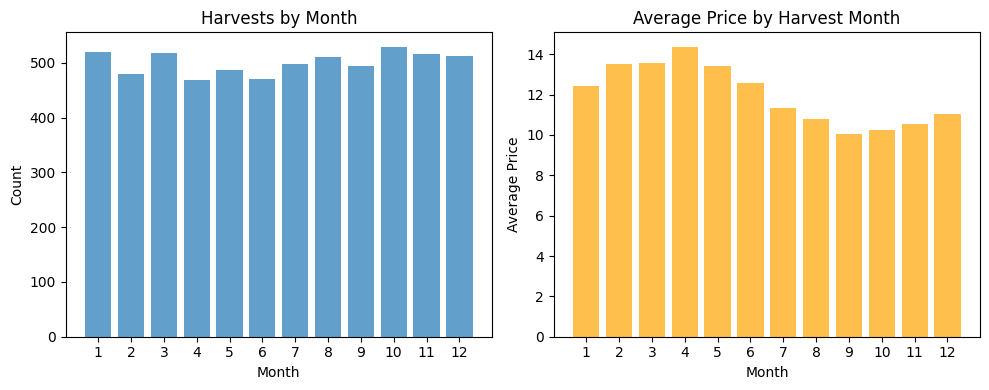

In [11]:
# Harvest date analysis
df['harvest_date'] = pd.to_datetime(df['harvest_date'])
df['harvest_month'] = df['harvest_date'].dt.month

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
monthly_counts = df['harvest_month'].value_counts().sort_index()
plt.bar(monthly_counts.index, monthly_counts.values, alpha=0.7)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Harvests by Month')
plt.xticks(range(1, 13))

plt.subplot(1, 2, 2)
monthly_prices = df.groupby('harvest_month')['price'].mean()
plt.bar(monthly_prices.index, monthly_prices.values, alpha=0.7, color='orange')
plt.xlabel('Month')
plt.ylabel('Average Price')
plt.title('Average Price by Harvest Month')
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [12]:
# Statistical summary of numeric columns
df.describe()

,farm_id,diameter,aspect_ratio,brix_index,skin_texture,temp_at_harvest,farmer_age,harvest_date,price,harvest_month
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000,6000.000000,6000.000000
mean,24.703167,7.976137,1.000711,12.016757,69.159732,24.971806,51.849333,2024-01-02 00:46:48,11.955786,6.547333
min,0.000000,2.245017,0.607760,4.287249,40.003982,7.335909,25.000000,2023-01-01 00:00:00,1.000000,1.000000
25%,12.000000,6.939870,0.933950,10.661977,54.239647,21.517912,38.000000,2023-07-07 00:00:00,7.682765,3.000000
50%,25.000000,7.974788,1.000941,12.025865,69.192904,24.998050,52.000000,2024-01-01 00:00:00,11.795904,7.000000
75%,37.000000,9.015594,1.067164,13.396937,83.786208,28.449768,66.000000,2024-06-30 00:00:00,15.942080,10.000000
max,49.000000,13.293583,1.342891,20.958169,98.984193,43.458123,79.000000,2024-12-30 00:00:00,36.566042,12.000000
std,14.369927,1.524700,0.099348,2.012184,16.976492,5.013258,15.925930,NaN,5.962436,3.480821


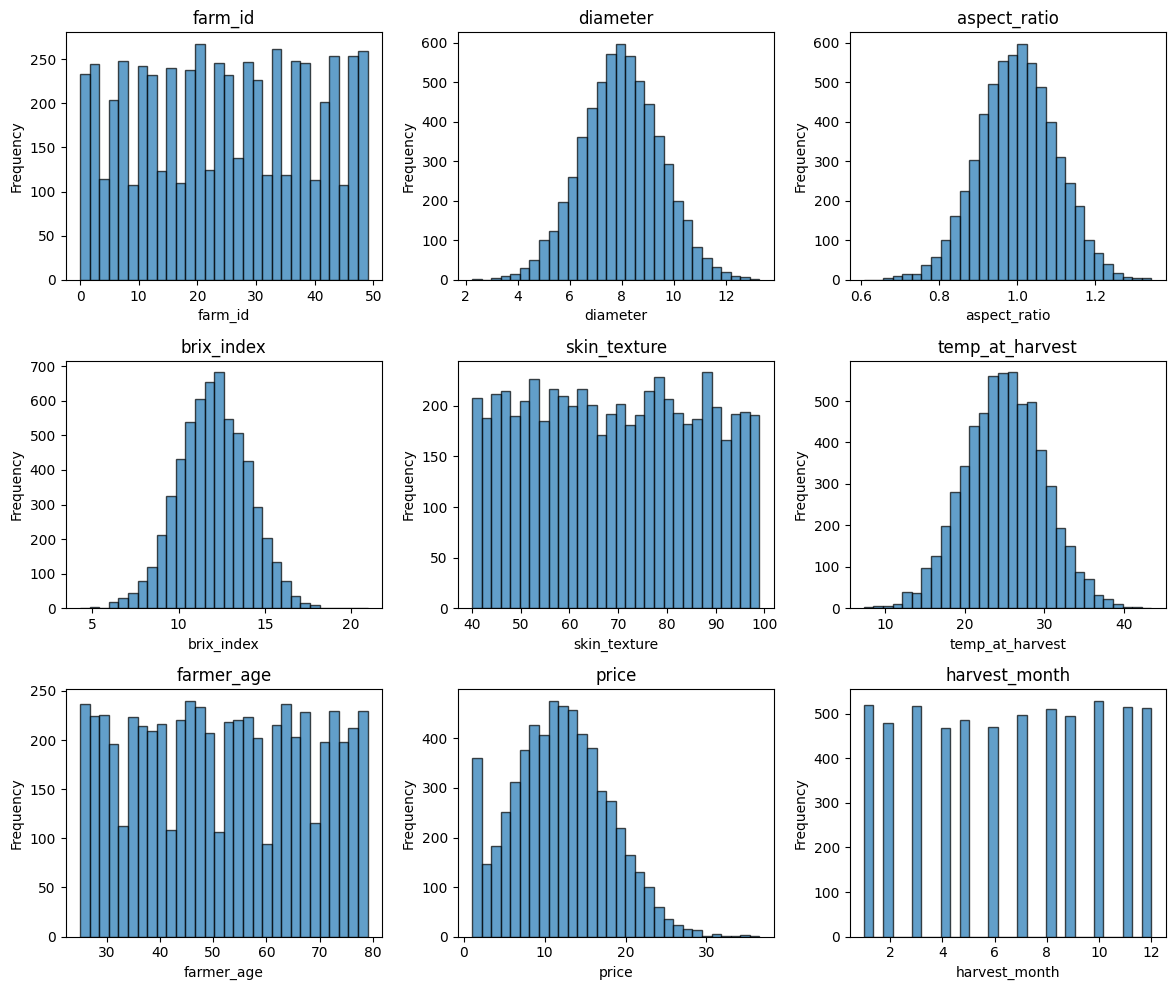

In [13]:
# Distribution of numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

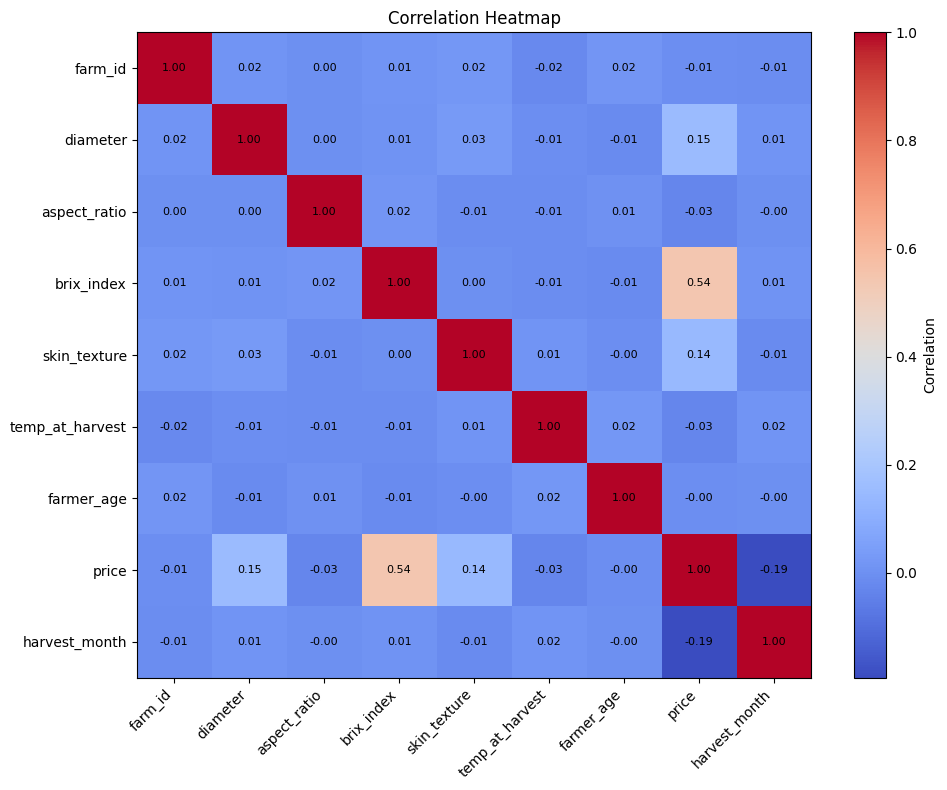

In [14]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha='right')
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title('Correlation Heatmap')

# Add correlation values as text
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        plt.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}', 
                ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

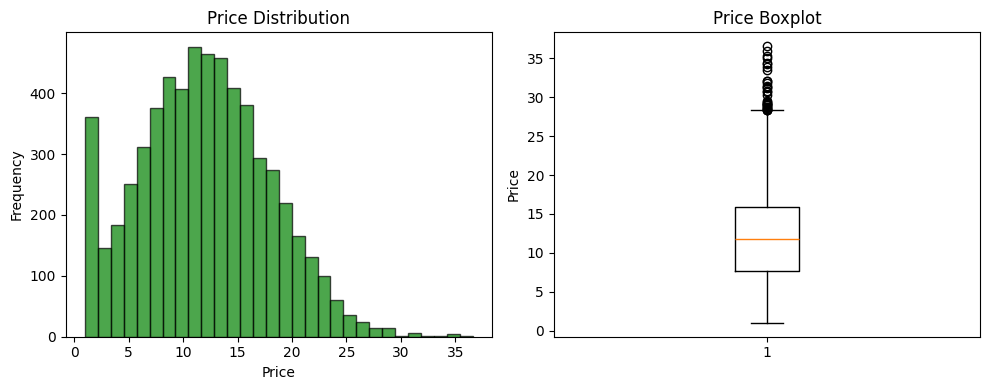

In [15]:
# Price distribution (target variable)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['price'], bins=30, edgecolor='black', alpha=0.7, color='green')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
plt.boxplot(df['price'])
plt.ylabel('Price')
plt.title('Price Boxplot')
plt.tight_layout()
plt.show()

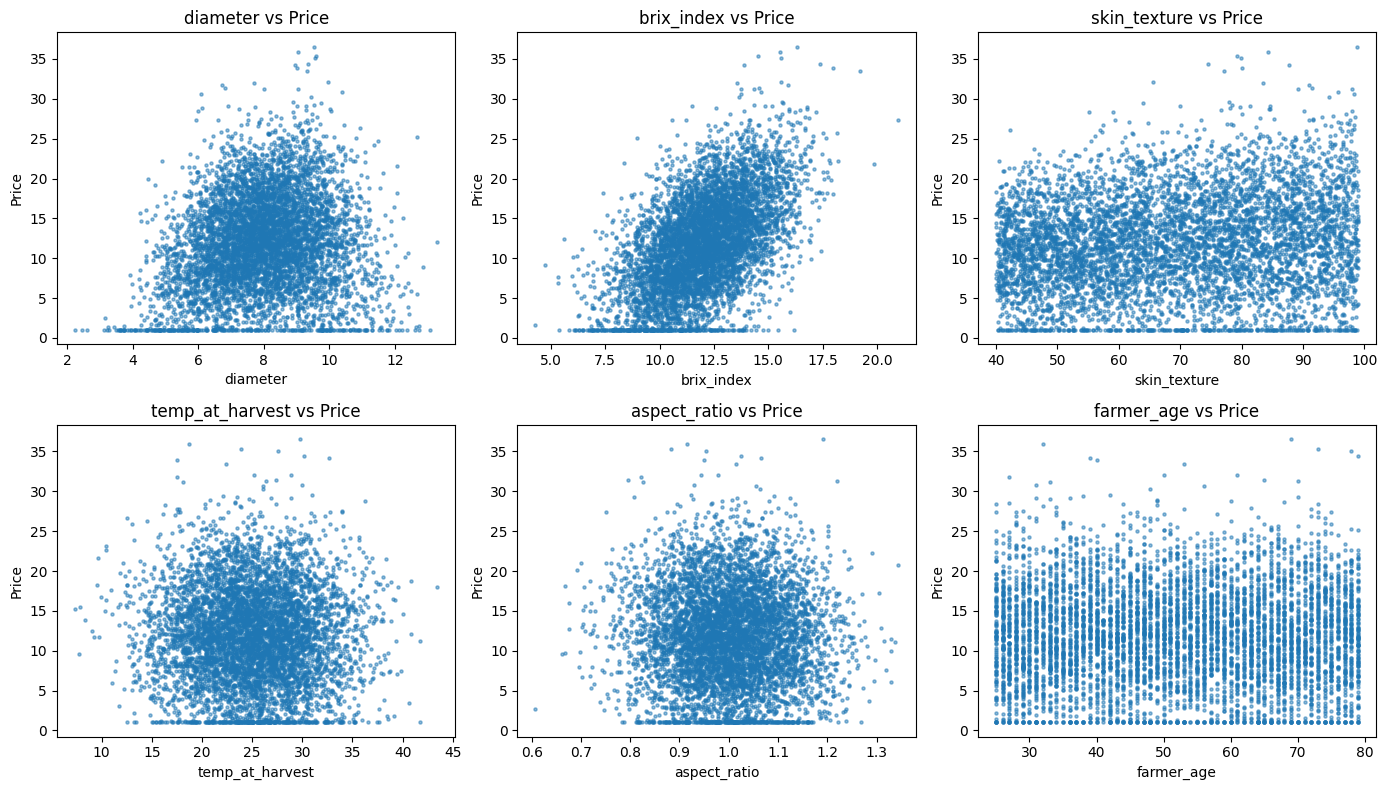

In [16]:
# Scatter plots: Key features vs Price
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features_to_plot = ['diameter', 'brix_index', 'skin_texture', 'temp_at_harvest', 'aspect_ratio', 'farmer_age']
for i, col in enumerate(features_to_plot):
    axes[i].scatter(df[col], df['price'], alpha=0.5, s=5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'{col} vs Price')

plt.tight_layout()
plt.show()

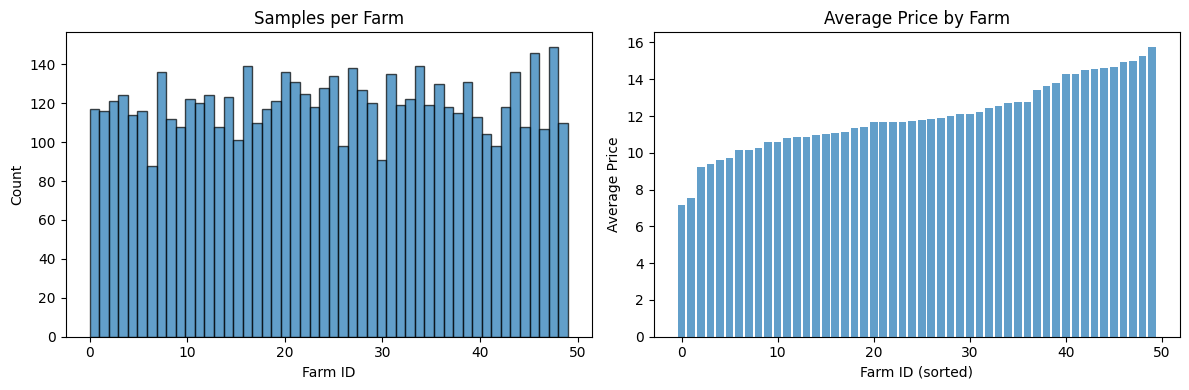

In [17]:
# Farm ID distribution and average price by farm
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['farm_id'], bins=len(df['farm_id'].unique()), edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Farm ID')
axes[0].set_ylabel('Count')
axes[0].set_title('Samples per Farm')

farm_avg_price = df.groupby('farm_id')['price'].mean().sort_values()
axes[1].bar(range(len(farm_avg_price)), farm_avg_price.values, alpha=0.7)
axes[1].set_xlabel('Farm ID (sorted)')
axes[1].set_ylabel('Average Price')
axes[1].set_title('Average Price by Farm')

plt.tight_layout()
plt.show()

# Model

In [18]:
# Modeling imports
from sklearn.model_selection import cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from xgboost import XGBRegressor

In [19]:
# Data Preprocessing
# Drop farmer_age (not predictive), drop harvest_date (already extracted month)
# Keep harvest_month as feature

feature_cols = ['farm_id', 'diameter', 'aspect_ratio', 'brix_index', 
                'skin_texture', 'temp_at_harvest', 'harvest_month']

X = df[feature_cols].copy()
y = df['price'].copy()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures:\n{X.head()}")

Features shape: (6000, 7)
Target shape: (6000,)

Features:
   farm_id   diameter  aspect_ratio  brix_index  skin_texture  \
0       38   5.728295      1.045636   12.415859     87.886484   
1       28   8.482390      0.963293   13.300979     70.578506   
2       14  10.632400      0.910341   13.329105     66.729040   
3       42   8.027602      1.057345   13.549547     81.926902   
4        7   8.337896      1.149167   11.263335     75.513572   

   temp_at_harvest  harvest_month  
0        15.330426             12  
1        17.529251             11  
2        33.272460              5  
3        32.509693              8  
4        28.766075             12  


In [20]:
# Target Encoder for farm_id (leak-safe implementation)
class TargetEncoder(BaseEstimator, TransformerMixin):
    """Encodes categorical features using target mean, fitted only on training data."""
    
    def __init__(self, cols=None, smoothing=1.0):
        self.cols = cols
        self.smoothing = smoothing
        self.encoding_map_ = {}
        self.global_mean_ = None
        
    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        if self.cols is None:
            self.cols = X.columns.tolist()
        
        self.global_mean_ = y.mean()
        
        for col in self.cols:
            # Calculate mean target per category
            agg = pd.DataFrame({'target': y, 'cat': X[col]}).groupby('cat')['target']
            means = agg.mean()
            counts = agg.count()
            
            # Apply smoothing: blend category mean with global mean
            smooth = (counts * means + self.smoothing * self.global_mean_) / (counts + self.smoothing)
            self.encoding_map_[col] = smooth.to_dict()
            
        return self
    
    def transform(self, X):
        X = pd.DataFrame(X).copy()
        for col in self.cols:
            X[col] = X[col].map(self.encoding_map_[col]).fillna(self.global_mean_)
        return X.values

In [21]:
# Cross-validation with proper target encoding (leak-safe)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate_model_cv(model_class, model_params, X, y, n_folds=5):
    """Run k-fold CV with target encoding applied within each fold."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    metrics = {'mse': [], 'rmse': [], 'mae': [], 'r2': []}
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Apply target encoding (fit only on training data)
        encoder = TargetEncoder(cols=['farm_id'], smoothing=10)
        X_train_encoded = encoder.fit_transform(X_train, y_train)
        X_val_encoded = encoder.transform(X_val)
        
        # Apply standard scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_encoded)
        X_val_scaled = scaler.transform(X_val_encoded)
        
        # Train model
        model = model_class(**model_params)
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_val_scaled)
        
        # Calculate metrics
        mse = mean_squared_error(y_val, y_pred)
        metrics['mse'].append(mse)
        metrics['rmse'].append(np.sqrt(mse))
        metrics['mae'].append(mean_absolute_error(y_val, y_pred))
        metrics['r2'].append(r2_score(y_val, y_pred))
    
    return {k: (np.mean(v), np.std(v)) for k, v in metrics.items()}

In [22]:
# Define models
models = {
    'Ridge Regression': (Ridge, {'alpha': 1.0}),
    'Random Forest': (RandomForestRegressor, {'n_estimators': 100, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}),
    'XGBoost': (XGBRegressor, {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'random_state': 42})
}

# Run 5-fold CV for each model
results = {}
for name, (model_class, params) in models.items():
    print(f"Training {name}...")
    results[name] = evaluate_model_cv(model_class, params, X, y, n_folds=5)
    print(f"  MSE: {results[name]['mse'][0]:.4f} ± {results[name]['mse'][1]:.4f}")
    print(f"  RMSE: {results[name]['rmse'][0]:.4f} ± {results[name]['rmse'][1]:.4f}")
    print(f"  MAE: {results[name]['mae'][0]:.4f} ± {results[name]['mae'][1]:.4f}")
    print(f"  R²: {results[name]['r2'][0]:.4f} ± {results[name]['r2'][1]:.4f}")
    print()

Training Ridge Regression...
  MSE: 19.3151 ± 0.6071
  RMSE: 4.3943 ± 0.0693
  MAE: 3.4404 ± 0.0689
  R²: 0.4559 ± 0.0236

Training Random Forest...
  MSE: 16.7215 ± 0.6043
  RMSE: 4.0885 ± 0.0740
  MAE: 3.1974 ± 0.0502
  R²: 0.5293 ± 0.0145

Training XGBoost...
  MSE: 16.2560 ± 0.3373
  RMSE: 4.0317 ± 0.0419
  MAE: 3.1388 ± 0.0154
  R²: 0.5422 ± 0.0148



In [23]:
# Results Summary Table
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MSE': [f"{results[m]['mse'][0]:.4f} ± {results[m]['mse'][1]:.4f}" for m in results],
    'RMSE': [f"{results[m]['rmse'][0]:.4f} ± {results[m]['rmse'][1]:.4f}" for m in results],
    'MAE': [f"{results[m]['mae'][0]:.4f} ± {results[m]['mae'][1]:.4f}" for m in results],
    'R²': [f"{results[m]['r2'][0]:.4f} ± {results[m]['r2'][1]:.4f}" for m in results],
})
results_df.set_index('Model', inplace=True)
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
results_df

MODEL COMPARISON SUMMARY


,MSE,RMSE,MAE,R²
Model,,,,
Ridge Regression,19.3151 ± 0.6071,4.3943 ± 0.0693,3.4404 ± 0.0689,0.4559 ± 0.0236
Random Forest,16.7215 ± 0.6043,4.0885 ± 0.0740,3.1974 ± 0.0502,0.5293 ± 0.0145
XGBoost,16.2560 ± 0.3373,4.0317 ± 0.0419,3.1388 ± 0.0154,0.5422 ± 0.0148


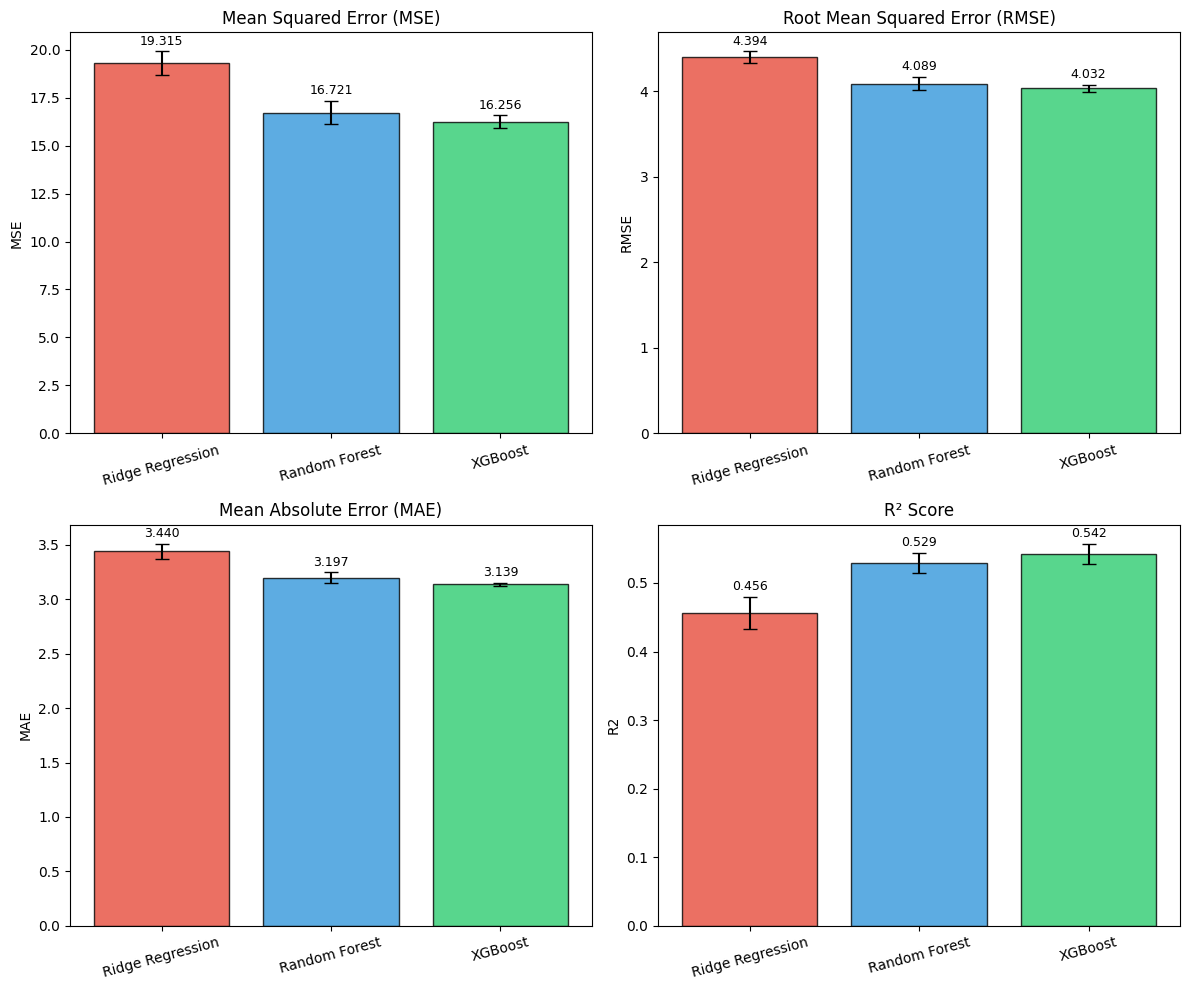


Chart saved to: model_comparison.png


In [24]:
# Bar charts comparing models across metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
metrics_to_plot = ['mse', 'rmse', 'mae', 'r2']
titles = ['Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)', 
          'Mean Absolute Error (MAE)', 'R² Score']
colors = ['#e74c3c', '#3498db', '#2ecc71']

for ax, metric, title in zip(axes.flatten(), metrics_to_plot, titles):
    model_names = list(results.keys())
    means = [results[m][metric][0] for m in model_names]
    stds = [results[m][metric][1] for m in model_names]
    
    bars = ax.bar(model_names, means, yerr=stds, capsize=5, color=colors, alpha=0.8, edgecolor='black')
    ax.set_ylabel(metric.upper())
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    
    # Add value labels on bars
    for bar, mean, std in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.01 * max(means),
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('/Users/user/gh-projects/llm_engineering/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to: model_comparison.png")

# Test Set Evaluation

In [25]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 4800 samples
Test set: 1200 samples


In [26]:
# Train all models on training set and evaluate on test set
# Apply target encoding (fit only on training data)
encoder = TargetEncoder(cols=['farm_id'], smoothing=10)
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

# Apply standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

# Train and evaluate each model
test_results = {}
trained_models = {}

for name, (model_class, params) in models.items():
    model = model_class(**params)
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    y_pred = model.predict(X_test_scaled)
    
    mse = mean_squared_error(y_test, y_pred)
    test_results[name] = {
        'mse': mse,
        'rmse': np.sqrt(mse),
        'mae': mean_absolute_error(y_test, y_pred),
        'r2': r2_score(y_test, y_pred),
        'predictions': y_pred
    }
    
    print(f"{name}:")
    print(f"  MSE:  {test_results[name]['mse']:.4f}")
    print(f"  RMSE: {test_results[name]['rmse']:.4f}")
    print(f"  MAE:  {test_results[name]['mae']:.4f}")
    print(f"  R²:   {test_results[name]['r2']:.4f}")
    print()

Ridge Regression:
  MSE:  20.1404
  RMSE: 4.4878
  MAE:  3.5580
  R²:   0.4280

Random Forest:
  MSE:  17.2430
  RMSE: 4.1525
  MAE:  3.2408
  R²:   0.5103

XGBoost:
  MSE:  16.6220
  RMSE: 4.0770
  MAE:  3.1458
  R²:   0.5280



In [27]:
# Test Set Results Summary
test_results_df = pd.DataFrame({
    'Model': list(test_results.keys()),
    'MSE': [test_results[m]['mse'] for m in test_results],
    'RMSE': [test_results[m]['rmse'] for m in test_results],
    'MAE': [test_results[m]['mae'] for m in test_results],
    'R²': [test_results[m]['r2'] for m in test_results],
})
test_results_df.set_index('Model', inplace=True)
print("=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
test_results_df

TEST SET RESULTS


,MSE,RMSE,MAE,R²
Model,,,,
Ridge Regression,20.140417,4.487808,3.558030,0.428043
Random Forest,17.243011,4.152470,3.240797,0.510325
XGBoost,16.622005,4.077009,3.145826,0.527961


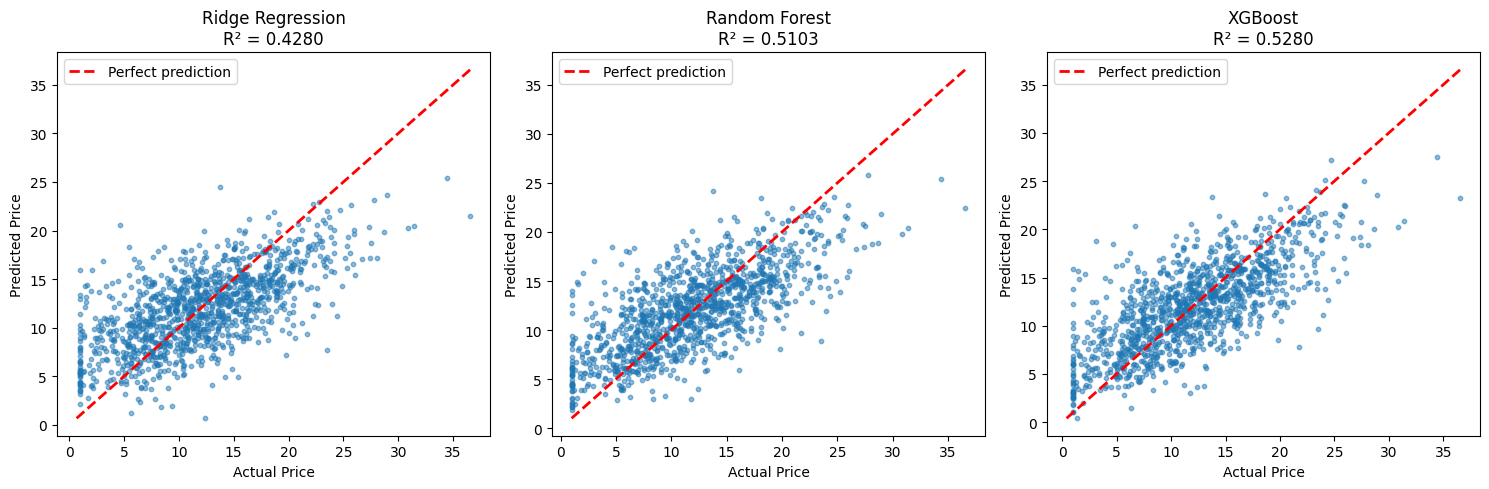

In [28]:
# Predictions vs Actuals visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, name in zip(axes, test_results.keys()):
    y_pred = test_results[name]['predictions']
    
    ax.scatter(y_test, y_pred, alpha=0.5, s=10)
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
    
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(f'{name}\nR² = {test_results[name]["r2"]:.4f}')
    ax.legend()

plt.tight_layout()
plt.show()

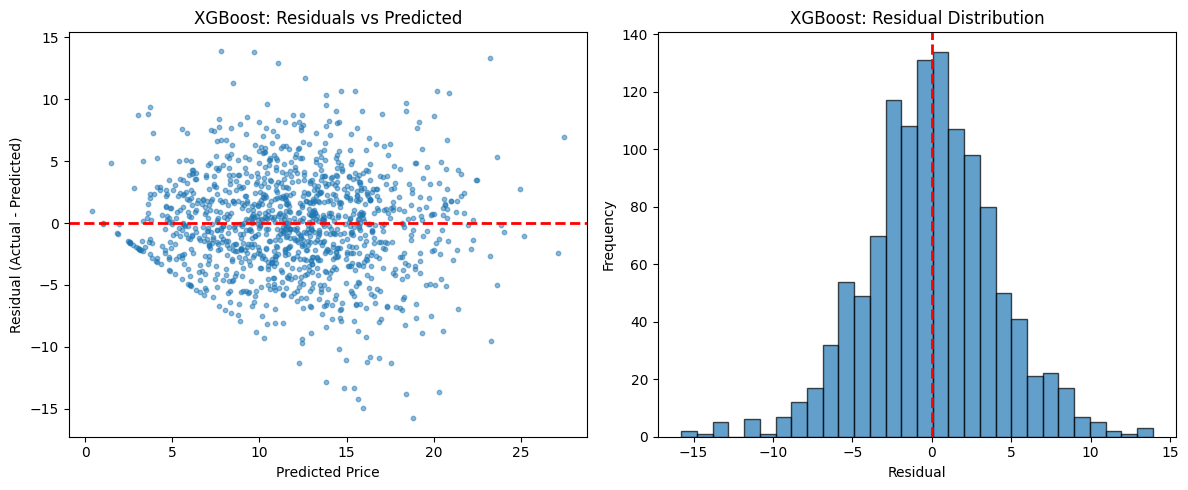

Residual stats for XGBoost:
  Mean: -0.0465
  Std:  4.0767


In [29]:
# Residual analysis for best model (XGBoost)
best_model = 'XGBoost'
y_pred_best = test_results[best_model]['predictions']
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_best, residuals, alpha=0.5, s=10)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'{best_model}: Residuals vs Predicted')

# Residuals distribution
axes[1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].set_title(f'{best_model}: Residual Distribution')

plt.tight_layout()
plt.show()

print(f"Residual stats for {best_model}:")
print(f"  Mean: {residuals.mean():.4f}")
print(f"  Std:  {residuals.std():.4f}")